In [30]:
import polars as pl
import matplotlib.pyplot as plt
from collections import Counter
dmgp1 = pl.read_csv('esea_master_dmg_demos.part1.csv')
dmgp2 = pl.read_csv('esea_master_dmg_demos.part2.csv')
dmg = pl.concat([dmgp1,dmgp2])
masterp1 = pl.read_csv("esea_master_kills_demos.part1.csv")
masterp2 = pl.read_csv("esea_master_kills_demos.part2.csv")
master = pl.concat([masterp1,masterp2])
metap1 = pl.read_csv("esea_meta_demos.part1.csv")
metap2 = pl.read_csv("esea_meta_demos.part2.csv")
meta = pl.concat([metap1,metap1])
meta = meta.select(pl.col("file"),pl.col("round"), pl.col("winner_side"))
master = master.select(pl.col("file"),pl.col("round"), pl.col("att_side"), pl.col("vic_side"), pl.col("ct_alive"), pl.col("t_alive"))
dmg = dmg.select(pl.col("file"), pl.col("round"), pl.col("att_id"), pl.col("vic_id"), pl.col("is_bomb_planted"))

In [31]:
# Counter terrorist

joined = meta.join(
    master,
    on=["file", "round"],
    how="inner"
)


joined = joined.filter((pl.col("ct_alive")==1) & (pl.col("t_alive") >1) & (pl.col("winner_side") == "CounterTerrorist"))

joined2 = joined.join(dmg,
    on=["file", "round"],
    how="inner"
)


joined2 = joined2.filter(((pl.col("att_side") != pl.col("vic_side"))))
joined2.shape
                         

joined2 = joined2.unique(["file", "round"])

clutchesct = (
    joined2
    .with_columns(
        pl.when(pl.col("att_side") == "CounterTerrorist")
        .then(pl.col("att_id"))
        .otherwise(
            pl.when(pl.col("vic_side") == "CounterTerrorist")
            .then(pl.col("vic_id"))
        )
        .alias("id")
    )
    .drop_nulls("id")
    .group_by("id")
    .agg(pl.len().alias("clutches"))
    .sort("clutches", descending=True)
)

In [32]:
joined = meta.join(
    master,
    on=["file", "round"],
    how="inner"
)


joined = joined.filter((pl.col("t_alive")==1) & (pl.col("ct_alive") >1) & (pl.col("winner_side") == "Terrorist"))

joined2 = joined.join(dmg,
    on=["file", "round"],
    how="inner"
                     )


joined2 = joined2.filter(((pl.col("att_side") != pl.col("vic_side"))))
joined2.shape
                         

joined2 = joined2.unique(["file", "round"])

clutchest = (
    joined2
    .with_columns(
        pl.when(pl.col("att_side") == "Terrorist")
        .then(pl.col("att_id"))
        .otherwise(
            pl.when(pl.col("vic_side") == "Terrorist")
            .then(pl.col("vic_id"))
        )
        .alias("id")
    )
    .group_by("id")
    .agg(pl.len().alias("clutches"))
    .sort("clutches", descending=True)
)

In [26]:
combined = (
    pl.concat([clutchest, clutchesct])
    .group_by("id")
    .agg(pl.col("clutches").sum().alias("clutches"))
    .sort("clutches", descending=True)
)
combined

id,clutches
i64,u32
76561198198967958,20
76561198049205149,16
76561198026939578,14
76561198128651804,13
76561198261826643,12
…,…
76561198138275315,1
76561198049753377,1
76561198848260137,1


In [33]:
dmg = pl.concat([dmgp1,dmgp2])
dmg1 = dmg.select(pl.col("att_id"), pl.col("hitbox"))
stats = (
    dmg1
    .group_by("att_id")
    .agg([
        pl.len().alias("total"),
        (pl.col("hitbox") == "Head").sum().alias("headshots")
    ])
)
stats = stats.with_columns(
    (pl.col("headshots") / pl.col("total")).alias("hs_rate")
)
stats = stats.rename({
    "att_id": "id",
    "total": "totalhits",
    "headshots": "headshots",
    "hs_rate": "headshotperhit"
})
players_per_round = (
    pl.concat([
        dmg.select([
            pl.col("file"),
            pl.col("round"),
            pl.col("att_id").alias("id")
        ]),
        dmg.select([
            pl.col("file"),
            pl.col("round"),
            pl.col("vic_id").alias("id")
        ])
    ])
    .unique()
    .group_by(["file", "round"])
    .agg(pl.len().alias("player_count"))
)


In [34]:
result = stats.join(combined, on="id", how="full").fill_null(0)
result = result.drop("id_right").filter(pl.col("id") != 0)

In [35]:
rounds_played = (
    pl.concat([
        dmg.select([
            pl.col("file"),
            pl.col("round"),
            pl.col("att_id").alias("id")
        ]),
        dmg.select([
            pl.col("file"),
            pl.col("round"),
            pl.col("vic_id").alias("id")
        ])
    ])
    .unique()
    .group_by("id")
    .agg(pl.len().alias("rounds_played"))
    .sort("rounds_played", descending=True)
)
rounds_played
print(rounds_played)
result

shape: (23_987, 2)
┌───────────────────┬───────────────┐
│ id                ┆ rounds_played │
│ ---               ┆ ---           │
│ i64               ┆ u32           │
╞═══════════════════╪═══════════════╡
│ 0                 ┆ 71378         │
│ 76561197960273630 ┆ 1823          │
│ 76561198118059131 ┆ 1785          │
│ 76561198175837893 ┆ 1646          │
│ 76561197983581393 ┆ 1493          │
│ …                 ┆ …             │
│ 76561198427684934 ┆ 1             │
│ 76561197960357336 ┆ 1             │
│ 76561198340487163 ┆ 1             │
│ 76561198101126535 ┆ 1             │
│ 76561198154948744 ┆ 1             │
└───────────────────┴───────────────┘


id,totalhits,headshots,headshotperhit,clutches
i64,u32,u32,f64,u32
76561198119186729,674,109,0.161721,0
76561198112766297,178,22,0.123596,0
76561197983014637,320,43,0.134375,0
76561198004653144,351,46,0.131054,0
76561198051062300,75,6,0.08,0
…,…,…,…,…
76561198053635056,50,6,0.12,0
76561197968812069,1565,224,0.143131,5
76561198120677733,1025,156,0.152195,1


In [36]:
rounds = rounds_played.filter(pl.col("id") != 0)
result = result.join(rounds, on = "id", how="full").fill_null(0)
result

id,totalhits,headshots,headshotperhit,clutches,id_right,rounds_played
i64,u32,u32,f64,u32,i64,u32
76561197960273630,4526,620,0.136986,2,76561197960273630,1823
76561198118059131,5564,915,0.16445,12,76561198118059131,1785
76561198175837893,4797,678,0.141338,8,76561198175837893,1646
76561197983581393,4818,721,0.149647,11,76561197983581393,1493
76561198283233285,4349,502,0.115429,7,76561198283233285,1446
…,…,…,…,…,…,…
76561198427684934,1,0,0.0,0,76561198427684934,1
0,0,0,0.0,0,76561197960357336,1
76561198340487163,7,0,0.0,0,76561198340487163,1


In [37]:
result = result.with_columns(
    (pl.col("headshots") / pl.col("rounds_played")).alias("headshots_per_round")
)
result = result.with_columns(
    (pl.col("totalhits") / pl.col("rounds_played")).alias("hits_per_round")
)

In [38]:
result = result.filter(pl.col("id") != 0)

In [39]:
result.write_csv("aggregated_stats.csv")
result.sort("headshots_per_round", descending = True).head(20)

id,totalhits,headshots,headshotperhit,clutches,id_right,rounds_played,headshots_per_round,hits_per_round
i64,u32,u32,f64,u32,i64,u32,f64,f64
76561197995918060,15,6,0.4,0,76561197995918060,4,1.5,3.75
76561198246034260,12,4,0.333333,0,76561198246034260,3,1.333333,4.0
76561198178491141,76,24,0.315789,0,76561198178491141,19,1.263158,4.0
76561197961585014,65,20,0.307692,0,76561197961585014,16,1.25,4.0625
76561198008846277,82,26,0.317073,0,76561198008846277,21,1.238095,3.904762
…,…,…,…,…,…,…,…,…
76561198071580990,97,15,0.154639,0,76561198071580990,14,1.071429,6.928571
76561198181056482,67,17,0.253731,0,76561198181056482,16,1.0625,4.1875
76561197961084681,69,21,0.304348,0,76561197961084681,20,1.05,3.45


In [40]:
result = result.select(pl.all().exclude("id_right"))
features = result.select([
    "headshotperhit",
    "clutches",
    "headshots_per_round",
    "hits_per_round"
])
import numpy as np
X = features.to_numpy()
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)
result = result.with_columns(
    pl.Series("cluster", labels)
)
cluster_summary = (
    result
    .group_by("cluster")
    .agg([
        pl.mean("headshotperhit"),
        pl.mean("clutches"),
        pl.mean("headshots_per_round"),
        pl.mean("hits_per_round")
    ])
)

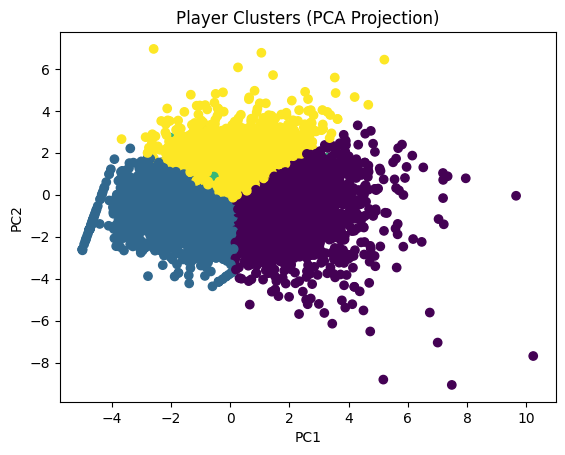

In [41]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Player Clusters (PCA Projection)")
plt.show()

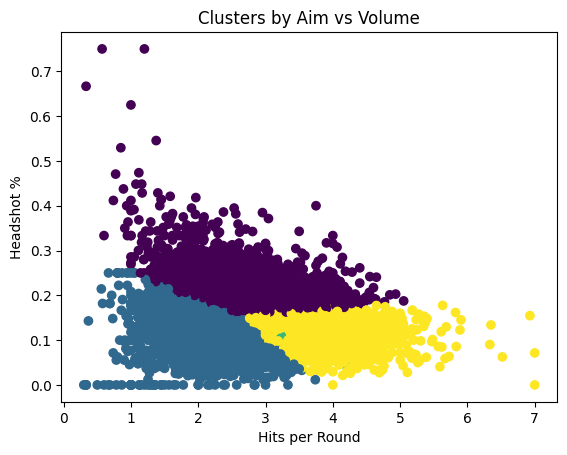

In [42]:
plt.figure()
plt.scatter(
    result["hits_per_round"],
    result["headshotperhit"],
    c=result["cluster"]
)
plt.xlabel("Hits per Round")
plt.ylabel("Headshot %")
plt.title("Clusters by Aim vs Volume")
plt.show()

In [43]:
cluster_summary

cluster,headshotperhit,clutches,headshots_per_round,hits_per_round
i32,f64,f64,f64,f64
3,0.122954,0.295182,0.416139,3.410473
1,0.118035,0.2958,0.277151,2.38809
2,0.142837,3.213992,0.401029,2.834499
0,0.201013,0.318152,0.541479,2.733941
